Linear Regression Model observing the average load and average delay on a stop by stop basis


domain


In [83]:
import import_ipynb
import route_delay_average_analysis as delay
import bus_ridership_routes as load_average
import pandas as pd

filename = "../datasets/MBTA-Bus-Arrival-Departure-Times_2024-12.csv"
df = pd.read_csv(filename, low_memory=False)


In [84]:

def preprocess_routes_to_dict(routes_df: pd.DataFrame, year: int = 2024):
    """
    Assumes all data belongs to `year`.  Returns:
      { year: {
          route_id: {
            stop_id: {
              (hour, hour+1): avg_delay_seconds,
              …
            }, …
          }, …
        }
      }
    Hours with no data → None.
    """
    
    df = routes_df.copy()
    
    routes_df = routes_df[~routes_df['route_id'].str.startswith(('600', '700', 'rad', '743', "171", "194"))]


    # parse timestamps & compute delay
    df['scheduled_dt']  = pd.to_datetime(df['scheduled'])
    df['actual_dt']     = pd.to_datetime(df['actual'])
    df['delay_seconds'] = (df['actual_dt'] - df['scheduled_dt']).dt.total_seconds()

    # drop ±1 hr outliers
    df = df[(df['delay_seconds'] >= -3600) & (df['delay_seconds'] <= 3600)]

    # extract hour of day
    df['hour'] = df['scheduled_dt'].dt.hour

    # avg delay per route/stop/hour
    avg = (
        df
        .groupby(['route_id','stop_id','hour'], as_index=False)
        ['delay_seconds']
        .mean()
        .rename(columns={'delay_seconds':'avg_delay_seconds'})
    )

    # make every (route,stop) × hour = 0–23
    pairs = df[['route_id','stop_id']].drop_duplicates()
    hours = pd.DataFrame({'hour': range(24)})
    pairs['key'] = 1
    hours['key'] = 1
    full = pairs.merge(hours, on='key').drop('key', axis=1)

    merged = (
        full
        .merge(avg, on=['route_id','stop_id','hour'], how='left')
        .sort_values(['route_id','stop_id','hour'])
        .reset_index(drop=True)
    )

    # build nested dict under the single year
    result_by_route = {}
    for _, row in merged.iterrows():
        route, stop, hr, avg_delay = (
            row['route_id'],
            row['stop_id'],
            int(row['hour']),
            row['avg_delay_seconds']
        )
        result_by_route\
            .setdefault(route, {})\
            .setdefault(stop, {})[(hr, hr+1)] = avg_delay

    return { year: result_by_route }

In [85]:
avg_positive_delay_per_hour = preprocess_routes_to_dict(df)


In [86]:
from pprint import pprint

pprint(avg_positive_delay_per_hour)

{2024: {'01': {2: {(0, 1): 208.91056910569105,
                   (1, 2): 291.54700854700855,
                   (2, 3): 140.47008547008548,
                   (3, 4): 174.24347826086955,
                   (4, 5): 227.95652173913044,
                   (5, 6): 204.5090909090909,
                   (6, 7): 1894.8333333333333,
                   (7, 8): nan,
                   (8, 9): nan,
                   (9, 10): 92.68,
                   (10, 11): 91.41584158415841,
                   (11, 12): 119.19847328244275,
                   (12, 13): 179.67295597484278,
                   (13, 14): 236.609756097561,
                   (14, 15): 129.82089552238807,
                   (15, 16): 148.21875,
                   (16, 17): 156.74149659863946,
                   (17, 18): 144.42635658914728,
                   (18, 19): 197.27731092436974,
                   (19, 20): 205.21768707482994,
                   (20, 21): 171.8074074074074,
                   (21, 22): 236.9933774834437,

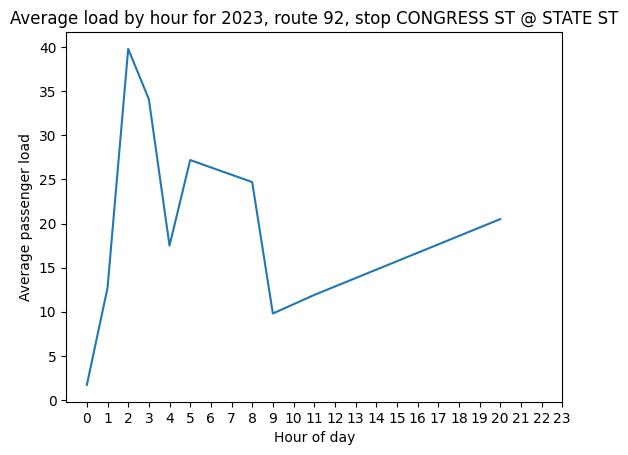

In [87]:
load_average.plot_hourly_average_load(load_average.hourly_load, "2023", route='92'
                        , stop='CONGRESS ST @ STATE ST')

In [145]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ──────────────────────────────────────────────────────────────────────────────
# 0) Flatten nested dicts into DataFrames
def flatten(d, col_name):
    records = []
    for year, routes in d.items():
        for route_id, stops in routes.items():
            for stop_id, value in stops.items():
                records.append({
                    "year":     year,
                    "route_id": route_id,
                    "stop_id":  stop_id,
                    col_name:   value
                })
    return pd.DataFrame(records)

df_load  = flatten(load_average.hourly_load,    "avg_load")
df_delay = flatten(avg_positive_delay_per_hour, "avg_delay")
df_count = flatten(load_average.hourly_counter, "bus_count")

# ──────────────────────────────────────────────────────────────────────────────
# 1) Dynamically unwrap any dict-valued metric into a float
def unwrap(x):
    if isinstance(x, dict):
        # take the first numeric value we find
        for v in x.values():
            if isinstance(v, (int, float)):
                return v
        return np.nan
    return x

for df, col in [(df_load, "avg_load"), (df_delay, "avg_delay"), (df_count, "bus_count")]:
    df[col] = df[col].apply(unwrap)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ──────────────────────────────────────────────────────────────────────────────
# 2) Align dtypes on our join-keys
for df in (df_load, df_delay, df_count):
    df["year"]     = df["year"].astype(int)
    df["route_id"] = df["route_id"].astype(str)
    df["stop_id"]  = df["stop_id"].astype(str)

# 3) Since delay is only 2024, filter load & count to 2024
df_load  = df_load[df_load["year"] == 2024]
df_count = df_count[df_count["year"] == 2024]

# ──────────────────────────────────────────────────────────────────────────────
# 4) Load your GTFS stops.txt to map stop_name → stop_id
stops = pd.read_csv(
    "../datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2024.csv",
    usecols=["stop_id","stop_name"]
)
stop_name_to_id = dict(zip(stops["stop_name"], stops["stop_id"]))

for df in (df_load, df_count):
    df["stop_id"] = df["stop_id"].map(stop_name_to_id)

# Re-align stop_id dtype now that we've remapped
for df in (df_load, df_delay, df_count):
    df["stop_id"] = df["stop_id"].astype(str)

# ──────────────────────────────────────────────────────────────────────────────
# 5) Debug: ensure there's actual overlap before merging
keys = {}
for name, dfi in [("load", df_load), ("delay", df_delay), ("count", df_count)]:
    ks = set(
        dfi
        .dropna(subset=["stop_id"]) 
        .apply(lambda r: (r.year, r.route_id, r.stop_id), axis=1)
    )
    keys[name] = ks
    print(f"{name:5s} unique keys: {len(ks)}")

common = keys["load"] & keys["delay"] & keys["count"]
print("common to all three:", len(common))
if not common:
    raise RuntimeError("No overlapping (year,route_id,stop_id) — fix your mappings or your source data")

# ──────────────────────────────────────────────────────────────────────────────
# 6) Three-way merge on year, route_id, stop_id
df = (
    df_load
      .merge(df_delay, on=["year","route_id","stop_id"], how="inner")
      .merge(df_count, on=["year","route_id","stop_id"], how="inner")
)
print("After merging, rows =", df.shape[0])

# 7) Drop any leftover NaNs in the target/feature columns
df = df.dropna(subset=["avg_load","avg_delay","bus_count"])

# ──────────────────────────────────────────────────────────────────────────────
# 8) Prepare X & y
num_features = ["avg_delay","bus_count"]
cat_features = ["year","route_id","stop_id"]

X = df[num_features + cat_features]
y = df["avg_load"]

# 9) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ──────────────────────────────────────────────────────────────────────────────
# 10) Pipeline: scale numerics, one-hot categoricals, fit LinearRegression
pipeline = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
    ])),
    ("linreg", LinearRegression()),
])
pipeline.fit(X_train, y_train)

# 11) Evaluate
y_pred = pipeline.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")

# 12) (Optional) 5-fold CV on the full dataset
cv = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
print("5-fold CV R²:", cv)
print("Avg CV R²:    ", cv.mean())

# ──────────────────────────────────────────────────────────────────────────────
# 13) Time‐aware prediction function
def predict_load_with_time(
    pipeline,
    route_id,
    stop_id,
    avg_delay,
    bus_count,
    *,
    dt=None,
    hour=None,
    year=2024
):
    """
    Estimate avg_load including time‐of‐day.

    Parameters
    ----------
    pipeline : trained sklearn Pipeline
        Must expect features ["year","route_id","stop_id",
                              "avg_delay","bus_count","hour_sin","hour_cos"].
    route_id : str or int
    stop_id  : str or int
    avg_delay: float
    bus_count: float
    dt       : str or pd.Timestamp, optional
    hour     : int, optional
    year     : int, default 2024

    Returns
    -------
    float
    """
    # 1) Determine hour
    if dt is not None:
        ts = pd.to_datetime(dt)
        hr = ts.hour
    elif hour is not None:
        hr = int(hour)
    else:
        raise ValueError("Must supply either dt or hour")
    
    # 2) Cyclical features
    sin_h = np.sin(2 * np.pi * hr / 24)
    cos_h = np.cos(2 * np.pi * hr / 24)
    
    # 3) Build input
    X_new = pd.DataFrame([{
        "year":      int(year),
        "route_id":  str(route_id),
        "stop_id":   str(stop_id),
        "avg_delay": float(avg_delay),
        "bus_count": float(bus_count),
        "hour_sin":  sin_h,
        "hour_cos":  cos_h,
    }])
    
    # 4) Predict & clip
    pred = pipeline.predict(X_new)[0]
    return max(0, pred)

# Example with hour:
# print(predict_load_with_time(pipeline, "22", "1039", 5.2, 4, hour=17))
# Example with datetime:
# print(predict_load_with_time(pipeline, "22", "1039", 5.2, 4, dt="2024-06-15 17:30:00"))


load  unique keys: 9838
delay unique keys: 2145
count unique keys: 9838
common to all three: 1549
After merging, rows = 1549
R²:   -0.013
RMSE: 88.804
MAE:  58.772
5-fold CV R²: [ 0.07529276 -0.04336534 -1.87279169 -0.1191704   0.00819979]
Avg CV R²:     -0.3903669776259682


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


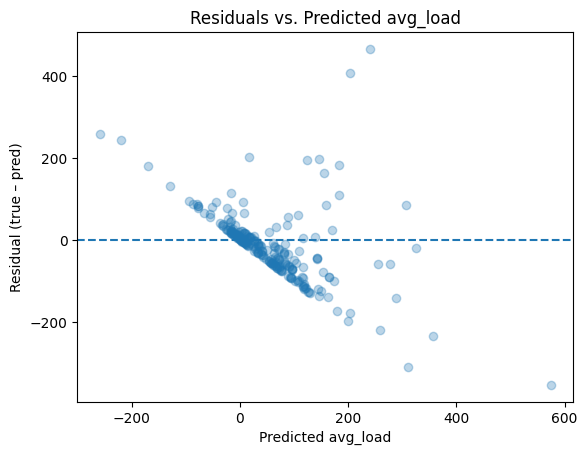

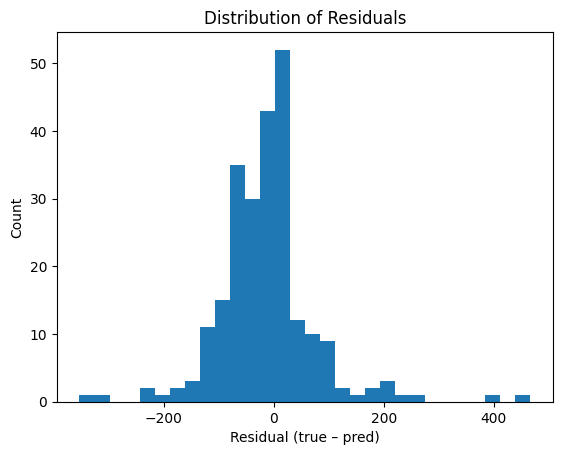

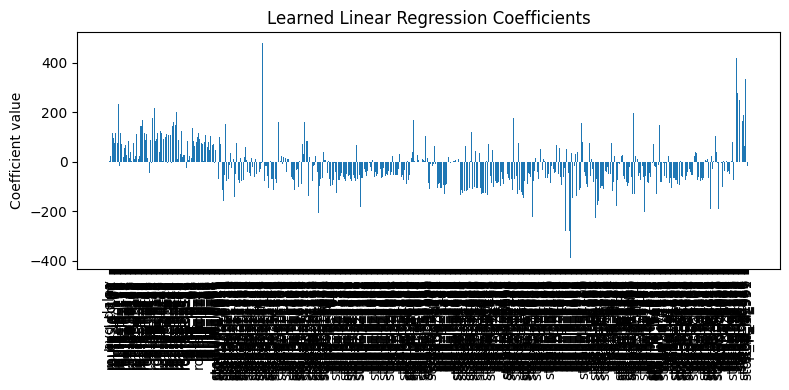

In [146]:
import matplotlib.pyplot as plt

# 1) Residuals vs. Predicted (test set)
y_pred = pipeline.predict(X_test)
resid  = y_test - y_pred

plt.figure()
plt.scatter(y_pred, resid, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted avg_load")
plt.ylabel("Residual (true – pred)")
plt.title("Residuals vs. Predicted avg_load")
plt.show()

# 2) Histogram of Residuals
plt.figure()
plt.hist(resid, bins=30)
plt.xlabel("Residual (true – pred)")
plt.ylabel("Count")
plt.title("Distribution of Residuals")
plt.show()

# 3) Feature Coefficients
linreg = pipeline.named_steps["linreg"]
# get names of all features after preprocessing
feature_names = (
    ["avg_delay", "bus_count"]
    + pipeline
        .named_steps["prep"]
        .named_transformers_["cat"]
        .get_feature_names_out(["year","route_id","stop_id"])
        .tolist()
)

plt.figure(figsize=(8,4))
plt.bar(range(len(linreg.coef_)), linreg.coef_)
plt.xticks(range(len(linreg.coef_)), feature_names, rotation=90)
plt.ylabel("Coefficient value")
plt.title("Learned Linear Regression Coefficients")
plt.tight_layout()
plt.show()


In [147]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_route_analysis(df, pipeline, target_routes):
    """
    Plots various diagnostics for specified routes:
      - Mean Absolute Error (MAE) bar chart
      - 2D scatter plots of avg_load vs avg_delay, avg_load vs bus_count, bus_count vs avg_delay
      - 3D scatter plot of avg_load vs avg_delay and bus_count

    Parameters:
    - df: DataFrame with ['year','route_id','stop_id','avg_load','avg_delay','bus_count']
    - pipeline: trained scikit-learn pipeline
    - target_routes: list of route_id strings to focus on
    """
    # Ensure predictions & residuals exist
    num_features = ["avg_delay", "bus_count"]
    cat_features = ["year", "route_id", "stop_id"]
    
    if "y_pred" not in df.columns:
        df["y_pred"] = pipeline.predict(df[num_features + cat_features])
    if "resid" not in df.columns:
        df["resid"] = df["avg_load"] - df["y_pred"]
    
    # Filter to target routes
    df_target = df[df["route_id"].isin(target_routes)]
    
    # 1) MAE per route bar chart
    route_mae = (
        df_target
        .groupby("route_id")["resid"]
        .apply(lambda x: np.mean(np.abs(x)))
        .reindex(target_routes)
    )
    plt.figure()
    plt.bar(route_mae.index, route_mae.values)
    plt.xlabel("Route ID")
    plt.ylabel("Mean Absolute Error (avg_load)")
    plt.title("Model MAE on Selected Routes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    
    # 2) Scatter: avg_delay vs avg_load
    plt.figure()
    plt.scatter(df_target["avg_delay"], df_target["avg_load"], alpha=0.5)
    plt.xlabel("Average Delay")
    plt.ylabel("Average Load")
    plt.title("avg_load vs avg_delay for Selected Routes")
    plt.tight_layout()
    plt.show()
    
    # 3) Scatter: bus_count vs avg_load
    plt.figure()
    plt.scatter(df_target["bus_count"], df_target["avg_load"], alpha=0.5)
    plt.xlabel("Bus Count")
    plt.ylabel("Average Load")
    plt.title("avg_load vs bus_count for Selected Routes")
    plt.tight_layout()
    plt.show()
    
    # 4) Scatter: avg_delay vs bus_count
    plt.figure()
    plt.scatter(df_target["avg_delay"], df_target["bus_count"], alpha=0.5)
    plt.xlabel("Average Delay")
    plt.ylabel("Bus Count")
    plt.title("bus_count vs avg_delay for Selected Routes")
    plt.tight_layout()
    plt.show()
    
    # 5) 3D scatter: avg_delay, bus_count, avg_load
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df_target["avg_delay"], df_target["bus_count"], df_target["avg_load"], alpha=0.5)
    ax.set_xlabel("Average Delay")
    ax.set_ylabel("Bus Count")
    ax.set_zlabel("Average Load")
    ax.set_title("3D Scatter: avg_load vs avg_delay & bus_count")
    plt.tight_layout()
    plt.show()

# Example usage:
# target = ["22","29","15","45","28","44","42","17","23","31","26","111","24","33","14"]
# plot_route_analysis(df, pipeline, target)


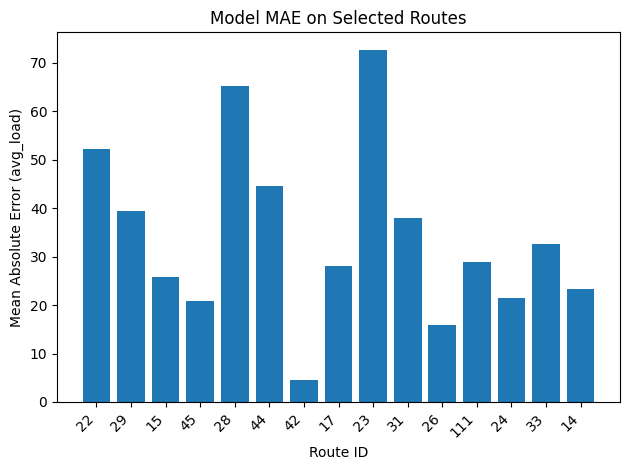

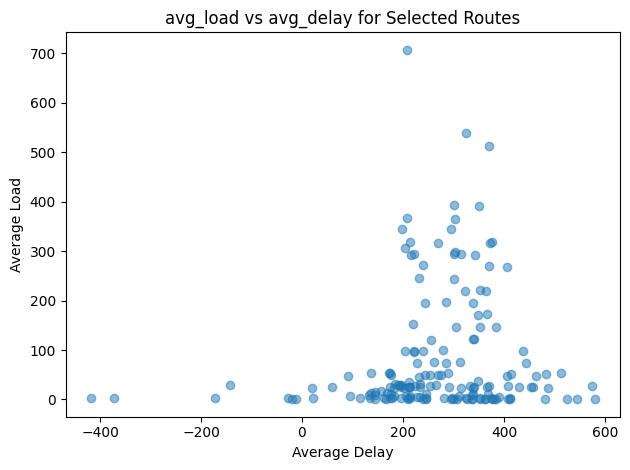

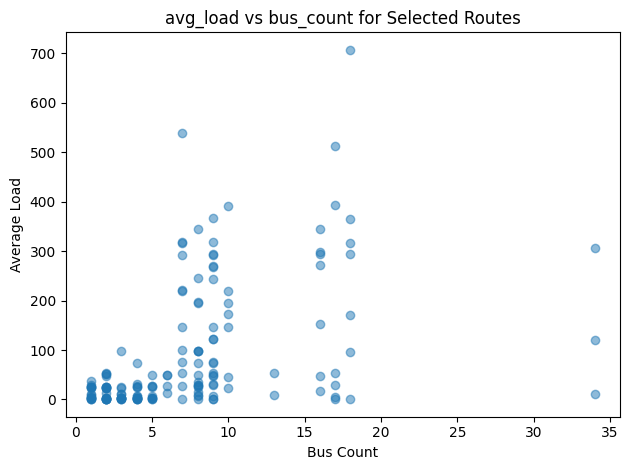

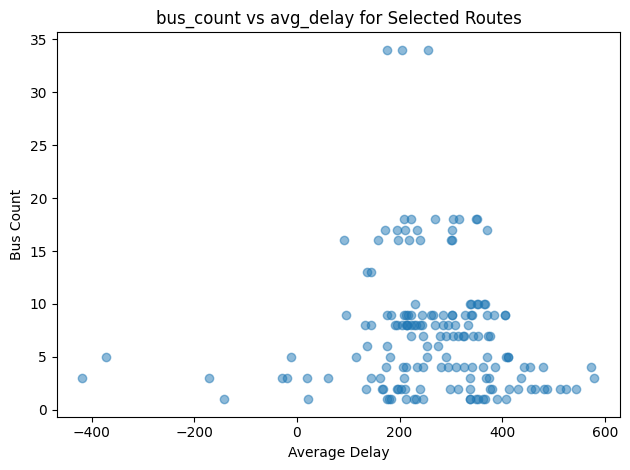

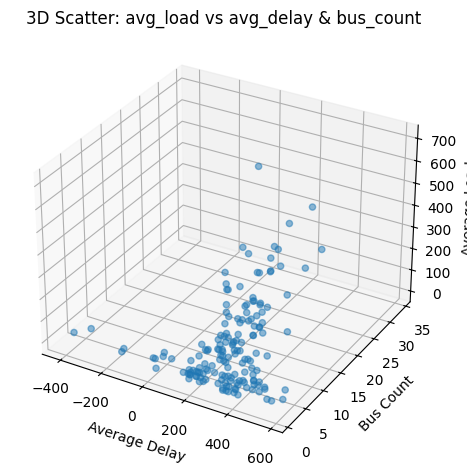

In [203]:
target = ["22","29","15","45","28","44","42","17","23","31","26","111","24","33","14"]
plot_route_analysis(df, pipeline, target)


In your bus‐load context, a lower MAE means your regression is, on average, more accurately estimating how many people are on the bus at a given stop based on delay and frequency.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Visual: Average load by hour for selected routes
def plot_avg_load_by_hour(df, routes, datetime_col=None, hour_col=None):
    # Ensure an hour column exists
    if hour_col and hour_col in df.columns:
        df['hour'] = df[hour_col].astype(int)
    elif datetime_col and datetime_col in df.columns:
        df['hour'] = pd.to_datetime(df[datetime_col]).dt.hour
    else:
        raise KeyError("Provide a valid datetime_col or hour_col")

    # Filter to selected routes
    df_sel = df[df['route_id'].isin(routes)]

    plt.figure()
    for route in routes:
        rd = df_sel[df_sel['route_id'] == route]
        if rd.empty:
            continue
        mean_load = rd.groupby('hour')['avg_load'].mean()
        plt.plot(mean_load.index, mean_load.values, marker='o', label=f"Route {route}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Load")
    plt.title("Average Load by Hour for Selected Routes")
    plt.legend()
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def predict_load_for(pipeline, route_id, stop_id, avg_delay, bus_count, hour, year=2024):
    """
    Predict avg_load for given route, stop, delay, frequency, and hour.
    Requires a pipeline trained on features:
      ["year","route_id","stop_id","avg_delay","bus_count","hour_sin","hour_cos"].
    """
    sin_h = np.sin(2 * np.pi * hour / 24)
    cos_h = np.cos(2 * np.pi * hour / 24)
    X_new = pd.DataFrame([{
        "year":      int(year),
        "route_id":  str(route_id),
        "stop_id":   str(stop_id),
        "avg_delay": float(avg_delay),
        "bus_count": float(bus_count),
        "hour_sin":  sin_h,
        "hour_cos":  cos_h,
    }])
    pred = pipeline.predict(X_new)[0]
    return max(0, pred)

def plot_predicted_load_by_hour(pipeline, route_id, stop_id, avg_delay, bus_count):
    """
    Plot predicted avg_load over 24 hours for specified route/stop/delay/frequency.
    """
    hours = np.arange(24)
    preds = [predict_load_for(pipeline, route_id, stop_id, avg_delay, bus_count, hour=h)
             for h in hours]
    
    plt.figure()
    plt.plot(hours, preds, marker='o')
    plt.xlabel("Hour of Day")
    plt.ylabel("Predicted Average Load")
    plt.title(f"Predicted Load by Hour for Route {route_id} Stop {stop_id}")
    plt.xticks(hours)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_predicted_load_by_hour(pipeline, route_id="22", stop_id="1039", avg_delay=5.2, bus_count=4)
# est = predict_load_for(pipeline, "22", "1039", avg_delay=5.2, bus_count=4, hour=17)
# print(f"Predicted load at 17:00: {est:.1f}")



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_hourly_actual_vs_predicted(df, pipeline, route_id, stop_id, datetime_col=None, hour_col=None):
    """
    Plots actual vs. predicted average load by hour for a given route and stop,
    using the pipeline and observed hourly avg_delay & bus_count.
    
    Parameters
    ----------
    df : DataFrame
        Must contain: ['avg_load','avg_delay','bus_count','route_id','stop_id']
        Plus either a datetime_col (timestamps) or an hour_col (0–23 ints).
    pipeline : sklearn Pipeline
        Trained with features ['year','route_id','stop_id','avg_delay',
        'bus_count','hour_sin','hour_cos'].
    route_id : str
    stop_id  : str
    datetime_col : str, optional
    hour_col     : str, optional
    """
    # 1) Ensure an 'hour' column
    if hour_col and hour_col in df.columns:
        df['hour'] = df[hour_col].astype(int)
    elif datetime_col and datetime_col in df.columns:
        df['hour'] = pd.to_datetime(df[datetime_col]).dt.hour
    else:
        raise KeyError("DataFrame must have a valid datetime_col or hour_col")
    
    # 2) Filter to the selected route & stop
    df_sub = df[(df['route_id'] == str(route_id)) & (df['stop_id'] == str(stop_id))].copy()
    if df_sub.empty:
        raise ValueError(f"No data for route {route_id} stop {stop_id}")
    
    # 3) Aggregate actual hourly means
    hourly = df_sub.groupby('hour').agg(
        avg_load=('avg_load', 'mean'),
        avg_delay=('avg_delay', 'mean'),
        bus_count=('bus_count', 'mean')
    ).reset_index().sort_values('hour')
    
    # 4) Compute cyclical time features
    hourly['hour_sin'] = np.sin(2 * np.pi * hourly['hour'] / 24)
    hourly['hour_cos'] = np.cos(2 * np.pi * hourly['hour'] / 24)
    
    # 5) Build feature matrix for prediction
    X_hourly = pd.DataFrame({
        'year':      [2024] * len(hourly),
        'route_id':  [str(route_id)] * len(hourly),
        'stop_id':   [str(stop_id)] * len(hourly),
        'avg_delay': hourly['avg_delay'],
        'bus_count': hourly['bus_count'],
        'hour_sin':  hourly['hour_sin'],
        'hour_cos':  hourly['hour_cos'],
    })
    
    # 6) Predict
    y_pred = pimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_hourly_actual_vs_predicted(df, pipeline,
                                    route_id, stop_id,
                                    datetime_col=None,
                                    hour_col=None):
    """
    Plots actual vs. predicted avg_load by hour for a given route & stop.
    Automatically casts the source hour column (or datetime) into an int hour.
    """
    # 1) Build an integer 'hour' column
    if datetime_col and datetime_col in df.columns:
        df['hour'] = pd.to_datetime(df[datetime_col]).dt.hour.astype(int)
    elif hour_col and hour_col in df.columns:
        # coerce to numeric then int
        df['hour'] = pd.to_numeric(df[hour_col], errors='coerce') \
                      .fillna(0).astype(int)
    else:
        raise KeyError("Need a valid datetime_col or hour_col in your DataFrame")
    
    # 2) Filter to the given route & stop
    df_sub = df[(df['route_id']==str(route_id)) & (df['stop_id']==str(stop_id))].copy()
    if df_sub.empty:
        raise ValueError(f"No data for route {route_id}, stop {stop_id}")
    
    # 3) Aggregate actual hourly means
    hourly = df_sub.groupby('hour').agg(
        avg_load=('avg_load','mean'),
        avg_delay=('avg_delay','mean'),
        bus_count=('bus_count','mean'),
    ).reset_index().sort_values('hour')
    
    # 4) Compute cyclical features
    hourly['hour_sin'] = np.sin(2*np.pi*hourly['hour']/24)
    hourly['hour_cos'] = np.cos(2*np.pi*hourly['hour']/24)
    
    # 5) Build feature matrix and predict
    Xh = pd.DataFrame({
        'year':      [2024]*len(hourly),
        'route_id':  [str(route_id)]*len(hourly),
        'stop_id':   [str(stop_id)]*len(hourly),
        'avg_delay': hourly['avg_delay'],
        'bus_count': hourly['bus_count'],
        'hour_sin':  hourly['hour_sin'],
        'hour_cos':  hourly['hour_cos'],
    })
    y_pred = pipeline.predict(Xh)
    
    # 6) Plot
    plt.figure()
    plt.plot(hourly['hour'], hourly['avg_load'], 'o-', label='Actual')
    plt.plot(hourly['hour'], y_pred, 's--', label='Predicted')
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Load")
    plt.title(f"Route {route_id} Stop {stop_id}: Actual vs Predicted")
    plt.xticks(hourly['hour'])
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
ipeline.predict(X_hourly)
    
    # 7) Plot actual vs predicted
    plt.figure()
    plt.plot(hourly['hour'], hourly['avg_load'], 'o-', label='Actual avg_load')
    plt.plot(hourly['hour'], y_pred, 's--', label='Predicted avg_load')
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Load")
    plt.title(f"Route {route_id} Stop {stop_id}: Actual vs Predicted by Hour")
    plt.xticks(hourly['hour'])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
# If your DataFrame has a datetime column:
# df['hour'] = pd.to_datetime(df['datetime']).dt.hour
# Then call:
# plot_hourly_actual_vs_predicted(df, pipeline, route_id="22", stop_id="1039", hour_col="hour")


Predicted load at 17:00 → 23.8 riders


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unkno

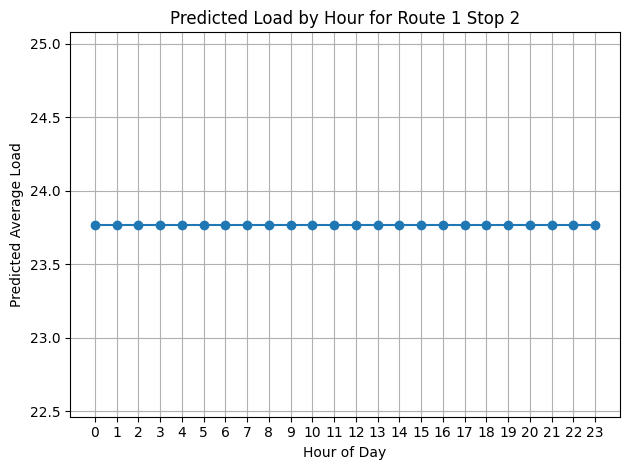

KeyError: "Column 'hour' not found in DataFrame."

In [216]:
# 1) Predict a single hour
pred_17 = predict_load_for(
    pipeline,
    route_id="1",
    stop_id="2",
    avg_delay=5.2,
    bus_count=10,
    hour=4
)
print(f"Predicted load at 17:00 → {pred_17:.1f} riders")

# 2) Plot the full day’s curve
plot_predicted_load_by_hour(
    pipeline,
    route_id="1",
    stop_id="2",
    avg_delay=5.2,
    bus_count=10
)

plot_hourly_actual_vs_predicted(
    df,
    pipeline,
    route_id="22",
    stop_id="1039",
    hour_col="hour"
)


KeyError: "Column 'hour' not found in DataFrame."